# SpMV Benchmark

In [ ]:
from collections import deque
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy.sparse as sparse
import spcraft
import sys
from matspy import spy
print(sys.executable)
print(spcraft.__file__)
print(spcraft.gen_er_graph)


/home/exouser/miniconda3/envs/tg/bin/python
/home/exouser/code/iusparse/python/spcraft/__init__.py
<function gen_er_graph at 0x76640d215440>


## ER Graph

In [11]:
def to_scipy_csr(matrix):
    return sparse.csr_array(
        (
            matrix.values,
            matrix.column_indices,
            matrix.row_offsets,
        ),
        shape=matrix.shape,
    )

er_spcraft = spcraft.gen_er_graph(
    vertices=50_000,
    expected_degree=16.0,
    seed=42,
)

er = to_scipy_csr(er_spcraft)


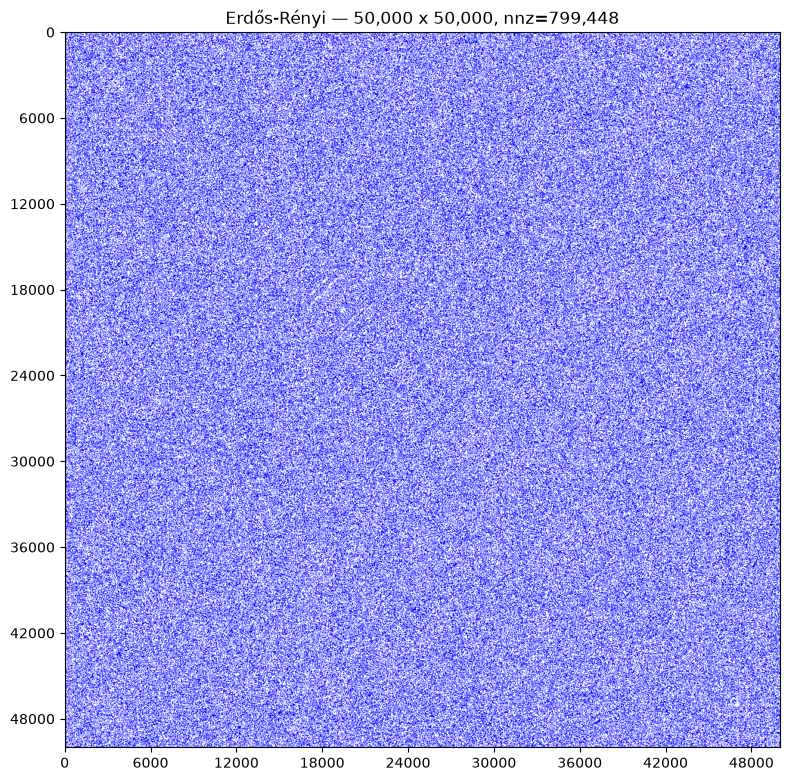

In [12]:

spy(
    er,
    title=f"Erdős-Rényi — {er.shape[0]:,} x {er.shape[1]:,}, nnz={er.nnz:,}",
    shading="binary",
    indices=True,
    figsize=8,
    buckets=1200,
)

## RMAT

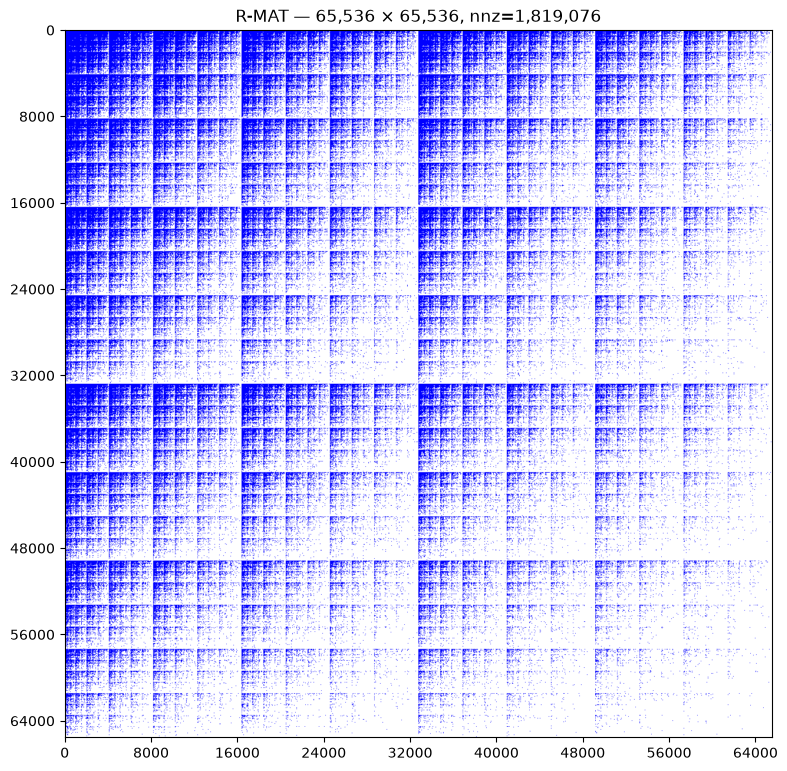

In [ ]:

rmat_spcraft = spcraft.gen_rmat(
      scale=16,       # 2**16 = 65,536 vertices
      edge_factor=16,
      seed=42,
  )

rmat = to_scipy_csr(rmat_spcraft)

spy(
      rmat,
      title=f"R-MAT — {rmat.shape[0]:,} x {rmat.shape[1]:,}, nnz={rmat.nnz:,}",
      shading="binary",
      indices=True,
      figsize=8,
      buckets=1200,
  )

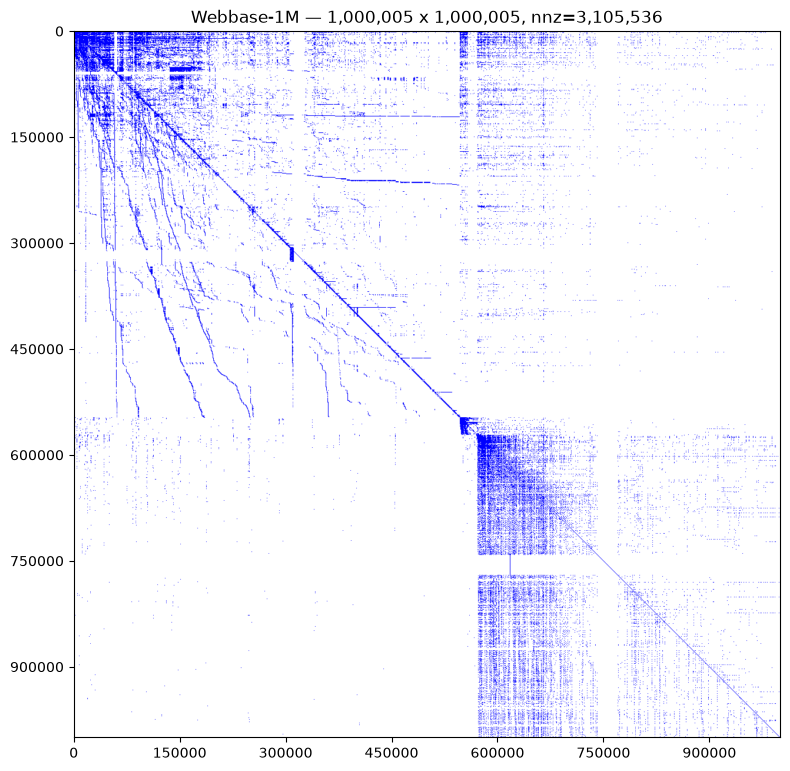

In [ ]:
webbase_path = Path("/home/exouser/code/spcraft/dataset/output/webbase-1M/webbase-1M.mtx")
webbase_spcraft = spcraft.from_matrix_market(webbase_path).to_csr()
webbase = to_scipy_csr(webbase_spcraft)
spy(
    webbase,
    title=(
        f"Webbase-1M — {webbase.shape[0]:,} x "
        f"{webbase.shape[1]:,}, nnz={webbase.nnz:,}"
    ),
    shading="binary",
    indices=True,
    figsize=8,
    buckets=1200,
)


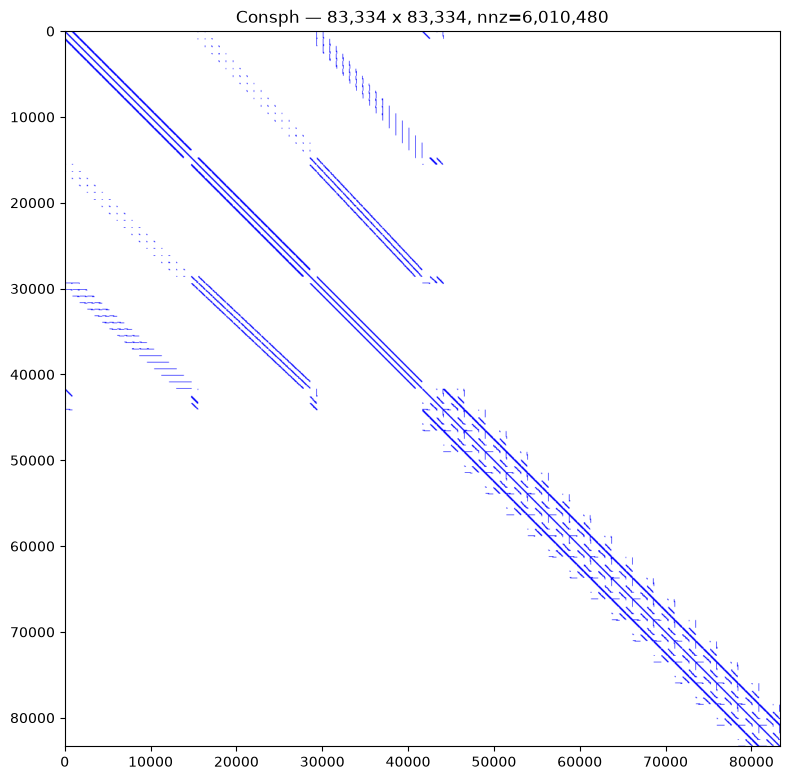

In [16]:
webbase_path = Path("/home/exouser/code/spcraft/dataset/output/consph/consph.mtx")
webbase_spcraft = spcraft.from_matrix_market(webbase_path).to_csr()
webbase = to_scipy_csr(webbase_spcraft)
spy(
    webbase,
    title=(
        f"Consph — {webbase.shape[0]:,} x "
        f"{webbase.shape[1]:,}, nnz={webbase.nnz:,}"
    ),
    shading="binary",
    indices=True,
    figsize=8,
    buckets=1200,
)
